In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn import preprocessing
from urllib.request import urlretrieve
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.io as pio
%matplotlib inline

pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',150)
sns.set_style('darkgrid')
matplotlib.rcParams['font.size']=14
matplotlib.rcParams['figure.figsize']=(10,6)
matplotlib.rcParams['figure.facecolor']='#00000000'

In [3]:
selected_cols=['fare_amount',	'pickup_datetime', 'pickup_longitude',	'pickup_latitude',	'dropoff_longitude',	'dropoff_latitude',	'passenger_count']
selected_cols

['fare_amount',
 'pickup_datetime',
 'pickup_longitude',
 'pickup_latitude',
 'dropoff_longitude',
 'dropoff_latitude',
 'passenger_count']

In [4]:
dtypes = {
	'fare_amount': 'float32',
	'pickup_longitude': 'float32',
	'pickup_latitude': 'float32',
	'dropoff_longitude': 'float32',
	'dropoff_latitude': 'float32',
	'passenger_count': 'uint8'
}
dtypes

{'fare_amount': 'float32',
 'pickup_longitude': 'float32',
 'pickup_latitude': 'float32',
 'dropoff_longitude': 'float32',
 'dropoff_latitude': 'float32',
 'passenger_count': 'uint8'}

In [5]:
import random
sample_fraction = 0.01
def skip_row(row_idx):
    if row_idx==0:
        return False
    return random.random()>sample_fraction

random.seed(42)
df=pd.read_csv('train.csv',usecols=selected_cols,dtype=dtypes, parse_dates=['pickup_datetime'], skiprows=skip_row)
df

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,4.0,2014-12-06 20:36:22+00:00,-73.979813,40.751904,-73.979446,40.755482,1
1,8.0,2013-01-17 17:22:00+00:00,0.000000,0.000000,0.000000,0.000000,2
2,8.9,2011-06-15 18:07:00+00:00,-73.996330,40.753223,-73.978897,40.766964,3
3,6.9,2009-12-14 12:33:00+00:00,-73.982430,40.745747,-73.982430,40.745747,1
4,7.0,2013-11-06 11:26:54+00:00,-73.959061,40.781059,-73.962059,40.768604,1
...,...,...,...,...,...,...,...
552445,45.0,2014-02-06 23:59:45+00:00,-73.973587,40.747669,-73.999916,40.602894,1
552446,22.5,2015-01-05 15:29:08+00:00,-73.935928,40.799656,-73.985710,40.726952,2
552447,4.5,2013-02-17 22:27:00+00:00,-73.992531,40.748619,-73.998436,40.740143,1
552448,14.5,2013-01-27 12:41:00+00:00,-74.012115,40.706635,-73.988724,40.756218,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 552450 entries, 0 to 552449
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   fare_amount        552450 non-null  float32            
 1   pickup_datetime    552450 non-null  datetime64[ns, UTC]
 2   pickup_longitude   552450 non-null  float32            
 3   pickup_latitude    552450 non-null  float32            
 4   dropoff_longitude  552450 non-null  float32            
 5   dropoff_latitude   552450 non-null  float32            
 6   passenger_count    552450 non-null  uint8              
dtypes: datetime64[ns, UTC](1), float32(5), uint8(1)
memory usage: 15.3 MB


In [7]:
df.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,552450.000000,552450.000000,552450.000000,552450.000000,552450.000000,552450.000000
mean,11.354059,-72.497063,39.910492,-72.504341,39.934258,1.684983
std,9.811924,11.618246,8.061114,12.074346,9.255058,1.337664
min,-52.000000,-1183.362793,-3084.490234,-3356.729736,-2073.150635,0.000000
25%,6.000000,-73.992020,40.734875,-73.991425,40.733990,1.000000
50%,8.500000,-73.981819,40.752621,-73.980179,40.753101,1.000000
75%,12.500000,-73.967155,40.767036,-73.963737,40.768059,2.000000
max,499.000000,2420.209473,404.983337,2467.752686,3351.403076,208.000000


In [8]:
df.isna().sum()

fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
dtype: int64

In [9]:
df['pickup_datetime'].min(),df['pickup_datetime'].max()

(Timestamp('2009-01-01 00:11:46+0000', tz='UTC'),
 Timestamp('2015-06-30 23:59:54+0000', tz='UTC'))

In [10]:
test_df=pd.read_csv('test.csv',dtype=dtypes,parse_dates=['pickup_datetime'])
test_df

,key,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2015-01-27 13:08:24.0000002,2015-01-27 13:08:24+00:00,-73.973320,40.763805,-73.981430,40.743835,1
1,2015-01-27 13:08:24.0000003,2015-01-27 13:08:24+00:00,-73.986862,40.719383,-73.998886,40.739201,1
2,2011-10-08 11:53:44.0000002,2011-10-08 11:53:44+00:00,-73.982521,40.751259,-73.979652,40.746140,1
3,2012-12-01 21:12:12.0000002,2012-12-01 21:12:12+00:00,-73.981163,40.767807,-73.990448,40.751637,1
4,2012-12-01 21:12:12.0000003,2012-12-01 21:12:12+00:00,-73.966049,40.789776,-73.988564,40.744427,1
...,...,...,...,...,...,...,...
9909,2015-05-10 12:37:51.0000002,2015-05-10 12:37:51+00:00,-73.968124,40.796997,-73.955643,40.780388,6
9910,2015-01-12 17:05:51.0000001,2015-01-12 17:05:51+00:00,-73.945511,40.803600,-73.960213,40.776371,6
9911,2015-04-19 20:44:15.0000001,2015-04-19 20:44:15+00:00,-73.991600,40.726608,-73.789742,40.647011,6
9912,2015-01-31 01:05:19.0000005,2015-01-31 01:05:19+00:00,-73.985573,40.735432,-73.939178,40.801731,6


In [11]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9914 entries, 0 to 9913
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   key                9914 non-null   object             
 1   pickup_datetime    9914 non-null   datetime64[ns, UTC]
 2   pickup_longitude   9914 non-null   float32            
 3   pickup_latitude    9914 non-null   float32            
 4   dropoff_longitude  9914 non-null   float32            
 5   dropoff_latitude   9914 non-null   float32            
 6   passenger_count    9914 non-null   uint8              
dtypes: datetime64[ns, UTC](1), float32(4), object(1), uint8(1)
memory usage: 319.6+ KB


In [12]:
test_df.describe()

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000
mean,-73.974724,40.751041,-73.973663,40.751740,1.671273
std,0.042774,0.033541,0.039072,0.035435,1.278747
min,-74.252190,40.573143,-74.263245,40.568974,1.000000
25%,-73.992500,40.736125,-73.991249,40.735253,1.000000
50%,-73.982327,40.753052,-73.980015,40.754065,1.000000
75%,-73.968012,40.767113,-73.964062,40.768757,2.000000
max,-72.986534,41.709557,-72.990967,41.696682,6.000000


In [13]:
test_df.isna().sum()

key                  0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
dtype: int64

In [14]:
test_df['pickup_datetime'].min(),test_df['pickup_datetime'].max()


(Timestamp('2009-01-01 11:04:24+0000', tz='UTC'),
 Timestamp('2015-06-30 20:03:50+0000', tz='UTC'))

****** 
***Preprocessing***

In [15]:
from sklearn.model_selection import train_test_split
train_df,val_df=train_test_split(df,test_size=0.2,random_state=42)

In [16]:
len(train_df),len(val_df)

(441960, 110490)

**filling missing data**

In [17]:
train_df=train_df.dropna()
val_df=val_df.dropna()

**extract inpust and targets from datasets**

In [18]:
input_cols=['pickup_longitude',	'pickup_latitude',	'dropoff_longitude',	'dropoff_latitude',	'passenger_count']
target_cols='fare_amount'

**training and validation inputs and targets**

In [19]:
train_inputs=train_df[input_cols]
train_targets=train_df[target_cols]
val_inputs=val_df[input_cols]
val_targets=val_df[target_cols]
test_inputs=test_df[input_cols]

In [20]:
train_inputs

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
353352,-73.993652,40.741543,-73.977974,40.742352,4
360070,-73.993805,40.724579,-73.993805,40.724579,1
372609,-73.959160,40.780750,-73.969116,40.761230,1
550895,-73.952187,40.783951,-73.978645,40.772602,1
444151,-73.977112,40.746834,-73.991104,40.750404,2
...,...,...,...,...,...
110268,-73.987152,40.750633,-73.979073,40.763168,1
259178,-73.972656,40.764042,-74.013176,40.707840,2
365838,-73.991982,40.749767,-73.989845,40.720551,3
131932,-73.969055,40.761398,-73.990814,40.751328,1


In [21]:
train_targets

353352     6.0
360070     3.7
372609    10.0
550895     8.9
444151     7.3
          ... 
110268     9.3
259178    18.5
365838    10.1
131932    10.9
121958     9.5
Name: fare_amount, Length: 441960, dtype: float32

In [22]:
val_inputs

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
15971,-73.995834,40.759190,-73.973679,40.739086,1
149839,-73.977386,40.738335,-73.976143,40.751205,1
515867,-73.983910,40.749470,-73.787170,40.646645,1
90307,-73.790794,40.643463,-73.972252,40.690182,1
287032,-73.976593,40.761944,-73.991463,40.750309,2
...,...,...,...,...,...
467556,-73.968567,40.761238,-73.983406,40.750019,3
19482,-73.986725,40.755920,-73.985855,40.731171,1
186063,0.000000,0.000000,0.000000,0.000000,1
382260,-73.980057,40.760334,-73.872589,40.774300,1


In [23]:
val_targets

15971     14.000000
149839     6.500000
515867    49.570000
90307     49.700001
287032     8.500000
            ...    
467556     6.100000
19482      7.300000
186063     4.500000
382260    32.900002
18838     11.500000
Name: fare_amount, Length: 110490, dtype: float32

In [24]:
test_inputs

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,-73.973320,40.763805,-73.981430,40.743835,1
1,-73.986862,40.719383,-73.998886,40.739201,1
2,-73.982521,40.751259,-73.979652,40.746140,1
3,-73.981163,40.767807,-73.990448,40.751637,1
4,-73.966049,40.789776,-73.988564,40.744427,1
...,...,...,...,...,...
9909,-73.968124,40.796997,-73.955643,40.780388,6
9910,-73.945511,40.803600,-73.960213,40.776371,6
9911,-73.991600,40.726608,-73.789742,40.647011,6
9912,-73.985573,40.735432,-73.939178,40.801731,6


****** 
***Train and evaluate Hardcoded Model***

In [25]:
class MeanRegressor:
    def fit(self,inputs,targets):
        self.mean=targets.mean()
    def predict(self,inputs):
        return np.full(inputs.shape[0],self.mean)

In [26]:
np.full(10,3)

array([3, 3, 3, 3, 3, 3, 3, 3, 3, 3])

In [27]:
mean_model=MeanRegressor()
mean_model.fit(train_inputs,train_targets)

In [28]:
mean_model.mean

np.float32(11.354714)

In [29]:
train_Pred=mean_model.predict(train_inputs)
train_Pred

array([11.354714, 11.354714, 11.354714, ..., 11.354714, 11.354714,
       11.354714], shape=(441960,), dtype=float32)

In [30]:
val_Pred=mean_model.predict(val_inputs)
val_Pred

array([11.354714, 11.354714, 11.354714, ..., 11.354714, 11.354714,
       11.354714], shape=(110490,), dtype=float32)

In [31]:
from sklearn.metrics import root_mean_squared_error
def rmse(targetts,preds):
    return root_mean_squared_error(targetts,preds)

In [32]:
print('RMSE of Training model: ',rmse(train_targets,train_Pred))
print('RMSE of Validation model: ',rmse(val_targets,val_Pred))

RMSE of Training model:  9.789782524108887
RMSE of Validation model:  9.899953842163086


****** 
***Train and evaluate Baseline Model***

In [33]:
from sklearn.linear_model import LinearRegression
lr_model=LinearRegression().fit(train_inputs,train_targets)

In [34]:
train_pred=lr_model.predict(train_inputs)
val_Pred=lr_model.predict(val_inputs)
train_Pred,val_Pred

(array([11.354714, 11.354714, 11.354714, ..., 11.354714, 11.354714,
        11.354714], shape=(441960,), dtype=float32),
 array([11.284328, 11.284496, 11.284781, ..., 11.8045  , 11.284434,
        11.284133], shape=(110490,), dtype=float32))

In [35]:
print('RMSE of Training model: ',rmse(train_targets,train_Pred))
print('RMSE of Validation model: ',rmse(val_targets,val_Pred))

RMSE of Training model:  9.789782524108887
RMSE of Validation model:  9.898087501525879


****** 
***Predict and Submit Models***

In [36]:
def predict_and_submit(model,test_inputs,fname):
    test_preds=model.predict(test_inputs)
    sub_df=pd.read_csv('sample_submission.csv')
    sub_df['fare_amount']=test_preds
    sub_df.to_csv(fname+'.csv',index=None)
    return sub_df

****** 
***Feature Engineering***

**Adding date specific features**

In [37]:
def add_dateparts(df,col):
 df[col+'_year']=df[col].dt.year
 df[col+'_month']=df[col].dt.month
 df[col+'_day']=df[col].dt.day
 df[col+'_weekday']=df[col].dt.weekday
 df[col+'_hour']=df[col].dt.hour

In [38]:
col='pickup_datetime'
df[col].dt.year

0         2014
1         2013
2         2011
3         2009
4         2013
          ... 
552445    2014
552446    2015
552447    2013
552448    2013
552449    2014
Name: pickup_datetime, Length: 552450, dtype: int32

In [39]:
add_dateparts(train_df,'pickup_datetime')
add_dateparts(val_df,'pickup_datetime')
add_dateparts(test_df,'pickup_datetime')

In [40]:
train_df

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_datetime_year,pickup_datetime_month,pickup_datetime_day,pickup_datetime_weekday,pickup_datetime_hour
353352,6.0,2015-04-12 03:40:38+00:00,-73.993652,40.741543,-73.977974,40.742352,4,2015,4,12,6,3
360070,3.7,2011-01-26 19:21:00+00:00,-73.993805,40.724579,-73.993805,40.724579,1,2011,1,26,2,19
372609,10.0,2012-10-03 10:40:17+00:00,-73.959160,40.780750,-73.969116,40.761230,1,2012,10,3,2,10
550895,8.9,2012-03-14 13:44:27+00:00,-73.952187,40.783951,-73.978645,40.772602,1,2012,3,14,2,13
444151,7.3,2012-02-05 15:33:00+00:00,-73.977112,40.746834,-73.991104,40.750404,2,2012,2,5,6,15
...,...,...,...,...,...,...,...,...,...,...,...,...
110268,9.3,2009-09-06 16:12:00+00:00,-73.987152,40.750633,-73.979073,40.763168,1,2009,9,6,6,16
259178,18.5,2009-04-12 09:58:56+00:00,-73.972656,40.764042,-74.013176,40.707840,2,2009,4,12,6,9
365838,10.1,2012-07-12 19:30:00+00:00,-73.991982,40.749767,-73.989845,40.720551,3,2012,7,12,3,19
131932,10.9,2011-02-17 18:33:00+00:00,-73.969055,40.761398,-73.990814,40.751328,1,2011,2,17,3,18


In [41]:
val_df

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_datetime_year,pickup_datetime_month,pickup_datetime_day,pickup_datetime_weekday,pickup_datetime_hour
15971,14.000000,2015-05-19 09:27:24+00:00,-73.995834,40.759190,-73.973679,40.739086,1,2015,5,19,1,9
149839,6.500000,2010-04-10 15:07:51+00:00,-73.977386,40.738335,-73.976143,40.751205,1,2010,4,10,5,15
515867,49.570000,2009-07-25 14:11:00+00:00,-73.983910,40.749470,-73.787170,40.646645,1,2009,7,25,5,14
90307,49.700001,2011-11-11 19:09:21+00:00,-73.790794,40.643463,-73.972252,40.690182,1,2011,11,11,4,19
287032,8.500000,2015-03-09 18:06:44+00:00,-73.976593,40.761944,-73.991463,40.750309,2,2015,3,9,0,18
...,...,...,...,...,...,...,...,...,...,...,...,...
467556,6.100000,2010-04-03 20:16:00+00:00,-73.968567,40.761238,-73.983406,40.750019,3,2010,4,3,5,20
19482,7.300000,2010-04-26 00:32:00+00:00,-73.986725,40.755920,-73.985855,40.731171,1,2010,4,26,0,0
186063,4.500000,2009-05-21 08:13:16+00:00,0.000000,0.000000,0.000000,0.000000,1,2009,5,21,3,8
382260,32.900002,2011-07-07 16:10:59+00:00,-73.980057,40.760334,-73.872589,40.774300,1,2011,7,7,3,16


In [42]:
test_df

,key,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_datetime_year,pickup_datetime_month,pickup_datetime_day,pickup_datetime_weekday,pickup_datetime_hour
0,2015-01-27 13:08:24.0000002,2015-01-27 13:08:24+00:00,-73.973320,40.763805,-73.981430,40.743835,1,2015,1,27,1,13
1,2015-01-27 13:08:24.0000003,2015-01-27 13:08:24+00:00,-73.986862,40.719383,-73.998886,40.739201,1,2015,1,27,1,13
2,2011-10-08 11:53:44.0000002,2011-10-08 11:53:44+00:00,-73.982521,40.751259,-73.979652,40.746140,1,2011,10,8,5,11
3,2012-12-01 21:12:12.0000002,2012-12-01 21:12:12+00:00,-73.981163,40.767807,-73.990448,40.751637,1,2012,12,1,5,21
4,2012-12-01 21:12:12.0000003,2012-12-01 21:12:12+00:00,-73.966049,40.789776,-73.988564,40.744427,1,2012,12,1,5,21
...,...,...,...,...,...,...,...,...,...,...,...,...
9909,2015-05-10 12:37:51.0000002,2015-05-10 12:37:51+00:00,-73.968124,40.796997,-73.955643,40.780388,6,2015,5,10,6,12
9910,2015-01-12 17:05:51.0000001,2015-01-12 17:05:51+00:00,-73.945511,40.803600,-73.960213,40.776371,6,2015,1,12,0,17
9911,2015-04-19 20:44:15.0000001,2015-04-19 20:44:15+00:00,-73.991600,40.726608,-73.789742,40.647011,6,2015,4,19,6,20
9912,2015-01-31 01:05:19.0000005,2015-01-31 01:05:19+00:00,-73.985573,40.735432,-73.939178,40.801731,6,2015,1,31,5,1


**Adding distance feature**

In [43]:
def haversine_np(lon1, lat1, lon2, lat2):
    """
    Calculate the great circle distance between two points
    on the earth (specified in decimal degrees)
    
    All args must be of equal length.    
    
    """
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    
    c = 2 * np.arcsin(np.sqrt(a))
    km = 6378.137 * c
    return km

In [44]:
def add_trip_distance(df):
    df['trip_distance']=haversine_np(df['pickup_longitude'],df['pickup_latitude'],df['dropoff_longitude'],df['dropoff_latitude'])

In [45]:
add_trip_distance(train_df)
add_trip_distance(val_df)
add_trip_distance(test_df)

In [46]:
train_df

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_datetime_year,pickup_datetime_month,pickup_datetime_day,pickup_datetime_weekday,pickup_datetime_hour,trip_distance
353352,6.0,2015-04-12 03:40:38+00:00,-73.993652,40.741543,-73.977974,40.742352,4,2015,4,12,6,3,1.325726
360070,3.7,2011-01-26 19:21:00+00:00,-73.993805,40.724579,-73.993805,40.724579,1,2011,1,26,2,19,0.000000
372609,10.0,2012-10-03 10:40:17+00:00,-73.959160,40.780750,-73.969116,40.761230,1,2012,10,3,2,10,2.329572
550895,8.9,2012-03-14 13:44:27+00:00,-73.952187,40.783951,-73.978645,40.772602,1,2012,3,14,2,13,2.563388
444151,7.3,2012-02-05 15:33:00+00:00,-73.977112,40.746834,-73.991104,40.750404,2,2012,2,5,6,15,1.245441
...,...,...,...,...,...,...,...,...,...,...,...,...,...
110268,9.3,2009-09-06 16:12:00+00:00,-73.987152,40.750633,-73.979073,40.763168,1,2009,9,6,6,16,1.552687
259178,18.5,2009-04-12 09:58:56+00:00,-73.972656,40.764042,-74.013176,40.707840,2,2009,4,12,6,9,7.128977
365838,10.1,2012-07-12 19:30:00+00:00,-73.991982,40.749767,-73.989845,40.720551,3,2012,7,12,3,19,3.257289
131932,10.9,2011-02-17 18:33:00+00:00,-73.969055,40.761398,-73.990814,40.751328,1,2011,2,17,3,18,2.149856


In [47]:
val_df

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_datetime_year,pickup_datetime_month,pickup_datetime_day,pickup_datetime_weekday,pickup_datetime_hour,trip_distance
15971,14.000000,2015-05-19 09:27:24+00:00,-73.995834,40.759190,-73.973679,40.739086,1,2015,5,19,1,9,2.914883
149839,6.500000,2010-04-10 15:07:51+00:00,-73.977386,40.738335,-73.976143,40.751205,1,2010,4,10,5,15,1.436299
515867,49.570000,2009-07-25 14:11:00+00:00,-73.983910,40.749470,-73.787170,40.646645,1,2009,7,25,5,14,20.167702
90307,49.700001,2011-11-11 19:09:21+00:00,-73.790794,40.643463,-73.972252,40.690182,1,2011,11,11,4,19,16.180342
287032,8.500000,2015-03-09 18:06:44+00:00,-73.976593,40.761944,-73.991463,40.750309,2,2015,3,9,0,18,1.802701
...,...,...,...,...,...,...,...,...,...,...,...,...,...
467556,6.100000,2010-04-03 20:16:00+00:00,-73.968567,40.761238,-73.983406,40.750019,3,2010,4,3,5,20,1.768046
19482,7.300000,2010-04-26 00:32:00+00:00,-73.986725,40.755920,-73.985855,40.731171,1,2010,4,26,0,0,2.756054
186063,4.500000,2009-05-21 08:13:16+00:00,0.000000,0.000000,0.000000,0.000000,1,2009,5,21,3,8,0.000000
382260,32.900002,2011-07-07 16:10:59+00:00,-73.980057,40.760334,-73.872589,40.774300,1,2011,7,7,3,16,9.192901


In [48]:
test_df

,key,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_datetime_year,pickup_datetime_month,pickup_datetime_day,pickup_datetime_weekday,pickup_datetime_hour,trip_distance
0,2015-01-27 13:08:24.0000002,2015-01-27 13:08:24+00:00,-73.973320,40.763805,-73.981430,40.743835,1,2015,1,27,1,13,2.325961
1,2015-01-27 13:08:24.0000003,2015-01-27 13:08:24+00:00,-73.986862,40.719383,-73.998886,40.739201,1,2015,1,27,1,13,2.428016
2,2011-10-08 11:53:44.0000002,2011-10-08 11:53:44+00:00,-73.982521,40.751259,-73.979652,40.746140,1,2011,10,8,5,11,0.619096
3,2012-12-01 21:12:12.0000002,2012-12-01 21:12:12+00:00,-73.981163,40.767807,-73.990448,40.751637,1,2012,12,1,5,21,1.963109
4,2012-12-01 21:12:12.0000003,2012-12-01 21:12:12+00:00,-73.966049,40.789776,-73.988564,40.744427,1,2012,12,1,5,21,5.393246
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9909,2015-05-10 12:37:51.0000002,2015-05-10 12:37:51+00:00,-73.968124,40.796997,-73.955643,40.780388,6,2015,5,10,6,12,2.126979
9910,2015-01-12 17:05:51.0000001,2015-01-12 17:05:51+00:00,-73.945511,40.803600,-73.960213,40.776371,6,2015,1,12,0,17,3.274802
9911,2015-04-19 20:44:15.0000001,2015-04-19 20:44:15+00:00,-73.991600,40.726608,-73.789742,40.647011,6,2015,4,19,6,20,19.205069
9912,2015-01-31 01:05:19.0000005,2015-01-31 01:05:19+00:00,-73.985573,40.735432,-73.939178,40.801731,6,2015,1,31,5,1,8.352739


**Distance from Popular landmark**

In [49]:
jfk_lonlat=-73.7781,40.6413
lga_lonlat=-73.8740,40.7769
ewr_lonlat=-74.1745,40.6895
met_lonlat=-73.9632,40.7794
wtc_lonlat=-74.0099,40.7126

In [50]:
def add_landmark_distance(df,landmark_name,landmark_lonlat):
    lan,lot=landmark_lonlat
    df[landmark_name+'_drop_distance']=haversine_np(lan,lot,df['dropoff_longitude'],df['dropoff_latitude'])

In [51]:
def add_landmark(df):
    landmarks=[('jfk',jfk_lonlat),('lga',lga_lonlat),('ewr',ewr_lonlat),('met',met_lonlat),('wtc',wtc_lonlat)]
    for name,lanlot in landmarks:
        add_landmark_distance(df,name,lanlot)

In [52]:
# add_landmark_distance(train_df,'JFK_Airport',jfk_lonlat)
# add_landmark_distance(train_df,'LGA_Airport',lga_lonlat)
# add_landmark_distance(train_df,'EWR_Airport',ewr_lonlat)
# add_landmark_distance(train_df,'MET_Meuseum',met_lonlat)
# add_landmark_distance(train_df,'World_trade_center',wtc_lonlat)

# add_landmark_distance(val_df,'JFK_Airport',jfk_lonlat)
# add_landmark_distance(val_df,'LGA_Airport',lga_lonlat)
# add_landmark_distance(val_df,'EWR_Airport',ewr_lonlat)
# add_landmark_distance(val_df,'MET_Meuseum',met_lonlat)
# add_landmark_distance(val_df,'World_trade_center',wtc_lonlat)

# add_landmark_distance(test_df,'JFK_Airport',jfk_lonlat)
# add_landmark_distance(test_df,'LGA_Airport',lga_lonlat)
# add_landmark_distance(test_df,'EWR_Airport',ewr_lonlat)
# add_landmark_distance(test_df,'MET_Meuseum',met_lonlat)
# add_landmark_distance(test_df,'World_trade_center',wtc_lonlat)


add_landmark(train_df)
add_landmark(val_df)
add_landmark(test_df)

In [53]:
train_df

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_datetime_year,pickup_datetime_month,pickup_datetime_day,pickup_datetime_weekday,pickup_datetime_hour,trip_distance,jfk_drop_distance,lga_drop_distance,ewr_drop_distance,met_drop_distance,wtc_drop_distance
353352,6.0,2015-04-12 03:40:38+00:00,-73.993652,40.741543,-73.977974,40.742352,4,2015,4,12,6,3,1.325726,20.276806,9.573071,17.595163,4.307908,4.269139
360070,3.7,2011-01-26 19:21:00+00:00,-73.993805,40.724579,-73.993805,40.724579,1,2011,1,26,2,19,0.000000,20.433201,11.661495,15.740635,6.625573,1.903542
372609,10.0,2012-10-03 10:40:17+00:00,-73.959160,40.780750,-73.969116,40.761230,1,2012,10,3,2,10,2.329572,20.931366,8.206596,19.078207,2.083055,6.414066
550895,8.9,2012-03-14 13:44:27+00:00,-73.952187,40.783951,-73.978645,40.772602,1,2012,3,14,2,13,2.563388,22.361820,8.834592,18.935209,1.505690,7.180877
444151,7.3,2012-02-05 15:33:00+00:00,-73.977112,40.746834,-73.991104,40.750404,2,2012,2,5,6,15,1.245441,21.695990,10.304610,16.893400,3.993929,4.497235
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110268,9.3,2009-09-06 16:12:00+00:00,-73.987152,40.750633,-73.979073,40.763168,1,2009,9,6,6,16,1.552687,21.718637,8.988900,18.413866,2.248164,6.200799
259178,18.5,2009-04-12 09:58:56+00:00,-73.972656,40.764042,-74.013176,40.707840,2,2009,4,12,6,9,7.128977,21.183916,14.031422,13.767856,9.012146,0.597548
365838,10.1,2012-07-12 19:30:00+00:00,-73.991982,40.749767,-73.989845,40.720551,3,2012,7,12,3,19,3.257289,19.934196,11.610144,15.961479,6.925673,1.909478
131932,10.9,2011-02-17 18:33:00+00:00,-73.969055,40.761398,-73.990814,40.751328,1,2011,2,17,3,18,2.149856,21.733032,10.251845,16.957403,3.896593,4.602038


In [54]:
val_df

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_datetime_year,pickup_datetime_month,pickup_datetime_day,pickup_datetime_weekday,pickup_datetime_hour,trip_distance,jfk_drop_distance,lga_drop_distance,ewr_drop_distance,met_drop_distance,wtc_drop_distance
15971,14.000000,2015-05-19 09:27:24+00:00,-73.995834,40.759190,-73.973679,40.739086,1,2015,5,19,1,9,2.914883,19.774555,9.400218,17.821142,4.573625,4.246299
149839,6.500000,2010-04-10 15:07:51+00:00,-73.977386,40.738335,-73.976143,40.751205,1,2010,4,10,5,15,1.436299,20.713839,9.074320,18.090454,3.322766,5.155434
515867,49.570000,2009-07-25 14:11:00+00:00,-73.983910,40.749470,-73.787170,40.646645,1,2009,7,25,5,14,20.167702,0.970032,16.245977,33.050793,20.952879,20.185898
90307,49.700001,2011-11-11 19:09:21+00:00,-73.790794,40.643463,-73.972252,40.690182,1,2011,11,11,4,19,16.180342,17.273691,12.722902,17.071575,9.960768,4.040044
287032,8.500000,2015-03-09 18:06:44+00:00,-73.976593,40.761944,-73.991463,40.750309,2,2015,3,9,0,18,1.802701,21.714895,10.336358,16.861692,4.020210,4.476777
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
467556,6.100000,2010-04-03 20:16:00+00:00,-73.968567,40.761238,-73.983406,40.750019,3,2010,4,3,5,20,1.768046,21.136189,9.697718,17.473629,3.687593,4.727179
19482,7.300000,2010-04-26 00:32:00+00:00,-73.986725,40.755920,-73.985855,40.731171,1,2010,4,26,0,0,2.756054,20.190014,10.718009,16.580769,5.698305,2.896652
186063,4.500000,2009-05-21 08:13:16+00:00,0.000000,0.000000,0.000000,0.000000,1,2009,5,21,3,8,0.000000,8656.396484,8667.153320,8690.284180,8674.595703,8677.095703
382260,32.900002,2011-07-07 16:10:59+00:00,-73.980057,40.760334,-73.872589,40.774300,1,2011,7,7,3,16,9.192901,16.816109,0.312896,27.161127,7.659788,13.464668


In [55]:
test_df

,key,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_datetime_year,pickup_datetime_month,pickup_datetime_day,pickup_datetime_weekday,pickup_datetime_hour,trip_distance,jfk_drop_distance,lga_drop_distance,ewr_drop_distance,met_drop_distance,wtc_drop_distance
0,2015-01-27 13:08:24.0000002,2015-01-27 13:08:24+00:00,-73.973320,40.763805,-73.981430,40.743835,1,2015,1,27,1,13,2.325961,20.610901,9.777240,17.377186,4.246758,4.226088
1,2015-01-27 13:08:24.0000003,2015-01-27 13:08:24+00:00,-73.986862,40.719383,-73.998886,40.739201,1,2015,1,27,1,13,2.428016,21.588675,11.335785,15.817243,5.392295,3.103555
2,2011-10-08 11:53:44.0000002,2011-10-08 11:53:44+00:00,-73.982521,40.751259,-73.979652,40.746140,1,2011,10,8,5,11,0.619096,20.630093,9.543493,17.607712,3.953624,4.522400
3,2012-12-01 21:12:12.0000002,2012-12-01 21:12:12+00:00,-73.981163,40.767807,-73.990448,40.751637,1,2012,12,1,5,21,1.963109,21.727304,10.212925,16.999334,3.850616,4.645160
4,2012-12-01 21:12:12.0000003,2012-12-01 21:12:12+00:00,-73.966049,40.789776,-73.988564,40.744427,1,2012,12,1,5,21,5.393246,21.150925,10.313868,16.837767,4.441519,3.974163
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9909,2015-05-10 12:37:51.0000002,2015-05-10 12:37:51+00:00,-73.968124,40.796997,-73.955643,40.780388,6,2015,5,10,6,12,2.126979,21.544802,6.892941,21.051773,0.646812,8.825333
9910,2015-01-12 17:05:51.0000001,2015-01-12 17:05:51+00:00,-73.945511,40.803600,-73.960213,40.776371,6,2015,1,12,0,17,3.274802,21.499725,7.267621,20.500252,0.421076,8.243552
9911,2015-04-19 20:44:15.0000001,2015-04-19 20:44:15+00:00,-73.991600,40.726608,-73.789742,40.647011,6,2015,4,19,6,20,19.205069,1.171150,16.112627,32.829693,20.770506,19.968605
9912,2015-01-31 01:05:19.0000005,2015-01-31 01:05:19+00:00,-73.985573,40.735432,-73.939178,40.801731,6,2015,1,31,5,1,8.352739,22.441605,6.149256,23.451723,3.206389,11.576398


****** 
***Removing Outliers and invalid data***

fare_amount: $1 to 500\
longitude: -75 to -72\
lattitude: 40 to 42\
passenger_count: 1 to 6

In [56]:
def remove_outliers(df):
    return df[(df['fare_amount'] >= 1.)& 
              (df['fare_amount'] <= 500.) & 
              (df['pickup_longitude'] >= -75) & 
              (df['pickup_longitude'] <= -72) & 
              (df['pickup_latitude'] >= 40) & 
              (df['pickup_latitude'] <= 42) & 
              (df['dropoff_longitude'] >= -75) & 
              (df['dropoff_longitude'] <= -72) & 
              (df['dropoff_latitude'] >= 40) & 
              (df['dropoff_latitude'] <= 42) & 
              (df['passenger_count'] >= 1) & 
              (df['passenger_count'] <= 6)]

In [57]:
train_df=remove_outliers(train_df)
val_df=remove_outliers(val_df)

In [58]:
train_df.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_datetime_year,pickup_datetime_month,pickup_datetime_day,pickup_datetime_weekday,pickup_datetime_hour,trip_distance,jfk_drop_distance,lga_drop_distance,ewr_drop_distance,met_drop_distance,wtc_drop_distance
count,431098.000000,431098.000000,431098.000000,431098.000000,431098.000000,431098.000000,431098.000000,431098.000000,431098.000000,431098.000000,431098.000000,431098.000000,431098.000000,431098.000000,431098.000000,431098.000000,431098.000000
mean,11.347896,-73.975121,40.750957,-73.974358,40.751320,1.690374,2011.737524,6.266821,15.732629,3.035066,13.506704,3.336340,20.949793,9.709977,18.507149,4.505338,5.978383
std,9.714552,0.039226,0.030028,0.038444,0.033221,1.306414,1.862116,3.436091,8.697833,1.950459,6.516894,3.748378,3.111016,3.096877,3.765751,3.811653,4.002031
min,1.000000,-74.839172,40.063896,-74.843079,40.054207,1.000000,2009.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.306118,0.116606,0.129472,0.031250,0.009297
25%,6.000000,-73.992249,40.736530,-73.991592,40.735497,1.000000,2010.000000,3.000000,8.000000,1.000000,9.000000,1.255575,20.554893,8.337903,16.506233,2.143929,3.592034
50%,8.500000,-73.982101,40.753319,-73.980606,40.753765,1.000000,2012.000000,6.000000,16.000000,3.000000,14.000000,2.157022,21.210662,9.537443,17.990210,3.727371,5.498291
75%,12.500000,-73.968399,40.767437,-73.965401,40.768360,2.000000,2013.000000,9.000000,23.000000,5.000000,19.000000,3.924069,21.936684,11.005392,19.819696,5.917221,7.654385
max,400.000000,-72.982796,41.787712,-72.935562,41.806301,6.000000,2015.000000,12.000000,31.000000,6.000000,23.000000,113.673119,130.592163,114.825356,125.594574,114.314293,121.817902


In [59]:
train_df.to_parquet('train.parquet')
val_df.to_parquet('val.parquet')
test_df.to_parquet('test.parquet')

****** 
***Training and Evaluate models***

In [60]:
train_df.columns

Index(['fare_amount', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'passenger_count',
       'pickup_datetime_year', 'pickup_datetime_month', 'pickup_datetime_day',
       'pickup_datetime_weekday', 'pickup_datetime_hour', 'trip_distance',
       'jfk_drop_distance', 'lga_drop_distance', 'ewr_drop_distance',
       'met_drop_distance', 'wtc_drop_distance'],
      dtype='object')

In [61]:
input_cols=['pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'passenger_count',
       'pickup_datetime_year', 'pickup_datetime_month', 'pickup_datetime_day',
       'pickup_datetime_weekday', 'pickup_datetime_hour', 'trip_distance',
       'jfk_drop_distance', 'lga_drop_distance', 'ewr_drop_distance',
       'met_drop_distance', 'wtc_drop_distance']
target_cols='fare_amount'

In [62]:
train_inputs=train_df[input_cols]
train_targets=train_df[target_cols]
val_inputs=val_df[input_cols]
val_targets=val_df[target_cols]
test_inputs=test_df[input_cols]

In [63]:
val_inputs

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_datetime_year,pickup_datetime_month,pickup_datetime_day,pickup_datetime_weekday,pickup_datetime_hour,trip_distance,jfk_drop_distance,lga_drop_distance,ewr_drop_distance,met_drop_distance,wtc_drop_distance
15971,-73.995834,40.759190,-73.973679,40.739086,1,2015,5,19,1,9,2.914883,19.774555,9.400218,17.821142,4.573625,4.246299
149839,-73.977386,40.738335,-73.976143,40.751205,1,2010,4,10,5,15,1.436299,20.713839,9.074320,18.090454,3.322766,5.155434
515867,-73.983910,40.749470,-73.787170,40.646645,1,2009,7,25,5,14,20.167702,0.970032,16.245977,33.050793,20.952879,20.185898
90307,-73.790794,40.643463,-73.972252,40.690182,1,2011,11,11,4,19,16.180342,17.273691,12.722902,17.071575,9.960768,4.040044
287032,-73.976593,40.761944,-73.991463,40.750309,2,2015,3,9,0,18,1.802701,21.714895,10.336358,16.861692,4.020210,4.476777
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
506435,-73.959457,40.774727,-73.966301,40.772179,1,2010,5,30,6,10,0.642886,21.552059,7.798357,19.828779,0.844938,7.583760
467556,-73.968567,40.761238,-73.983406,40.750019,3,2010,4,3,5,20,1.768046,21.136189,9.697718,17.473629,3.687593,4.727179
19482,-73.986725,40.755920,-73.985855,40.731171,1,2010,4,26,0,0,2.756054,20.190014,10.718009,16.580769,5.698305,2.896652
382260,-73.980057,40.760334,-73.872589,40.774300,1,2011,7,7,3,16,9.192901,16.816109,0.312896,27.161127,7.659788,13.464668


In [64]:
def eval_model(model):
    train_pred=model.predict(train_inputs)
    val_pred=model.predict(val_inputs)
    train_rmse=rmse(train_targets,train_pred)
    val_rmse=rmse(val_targets,val_pred)
    return train_rmse,val_rmse,train_pred,val_pred

**Ridge Regression**

In [65]:
from sklearn.linear_model import Ridge
model_ridge=Ridge(random_state=42,alpha=0.9).fit(train_inputs,train_targets)
train_rmse,val_rmse,train_pred,val_pred=eval_model(model_ridge)
print('train rmse: ',train_rmse)
print('val rmse: ',val_rmse)
print('train pred: ',train_Pred)
print('val pred: ',val_Pred)

train rmse:  5.04931404456351
val rmse:  5.21784562179922
train pred:  [11.354714 11.354714 11.354714 ... 11.354714 11.354714 11.354714]
val pred:  [11.284328 11.284496 11.284781 ... 11.8045   11.284434 11.284133]


**Saving the submission**

In [66]:
predict_and_submit(model=model_ridge,test_inputs=test_inputs,fname='Ridge_submissions')

,key,fare_amount
0,2015-01-27 13:08:24.0000002,10.081973
1,2015-01-27 13:08:24.0000003,11.400097
2,2011-10-08 11:53:44.0000002,5.356944
3,2012-12-01 21:12:12.0000002,8.763522
4,2012-12-01 21:12:12.0000003,14.609350
...,...,...
9909,2015-05-10 12:37:51.0000002,9.024145
9910,2015-01-12 17:05:51.0000001,11.217691
9911,2015-04-19 20:44:15.0000001,47.927673
9912,2015-01-31 01:05:19.0000005,22.600264


**Random Forest**

In [68]:
%%time
from sklearn.ensemble import RandomForestRegressor
model_rf=RandomForestRegressor(random_state=42,n_jobs=-1,max_depth=10,n_estimators=100).fit(train_inputs,train_targets)

CPU times: total: 17min 30s
Wall time: 1min 42s


In [70]:
train_rmse,val_rmse,train_pred,val_pred=eval_model(model_rf)
print('train rmse: ',train_rmse)
print('val rmse: ',val_rmse)
print('train pred: ',train_Pred)
print('val pred: ',val_Pred)

train rmse:  3.5948138062113486
val rmse:  4.161053852715499
train pred:  [11.354714 11.354714 11.354714 ... 11.354714 11.354714 11.354714]
val pred:  [11.284328 11.284496 11.284781 ... 11.8045   11.284434 11.284133]


**Saving the submission**

In [72]:
predict_and_submit(model=model_rf,test_inputs=test_inputs,fname='rf_submissions')

,key,fare_amount
0,2015-01-27 13:08:24.0000002,10.479748
1,2015-01-27 13:08:24.0000003,10.468653
2,2011-10-08 11:53:44.0000002,5.046148
3,2012-12-01 21:12:12.0000002,8.481902
4,2012-12-01 21:12:12.0000003,14.300694
...,...,...
9909,2015-05-10 12:37:51.0000002,8.694722
9910,2015-01-12 17:05:51.0000001,12.535128
9911,2015-04-19 20:44:15.0000001,55.355344
9912,2015-01-31 01:05:19.0000005,21.467722


**Gradient Boosting**

In [74]:
from xgboost import XGBRegressor
model_xgb=XGBRegressor(max_depth=5,objective='reg:squarederror',n_estimators=200,random_state=42,n_jobs=-1).fit(train_inputs,train_targets)

In [75]:
train_rmse,val_rmse,train_pred,val_pred=eval_model(model_xgb)
print('train rmse: ',train_rmse)
print('val rmse: ',val_rmse)
print('train pred: ',train_Pred)
print('val pred: ',val_Pred)

train rmse:  3.1910603046417236
val rmse:  4.013364791870117
train pred:  [11.354714 11.354714 11.354714 ... 11.354714 11.354714 11.354714]
val pred:  [11.284328 11.284496 11.284781 ... 11.8045   11.284434 11.284133]


**Saving the submission**

In [76]:
predict_and_submit(model=model_xgb,test_inputs=test_inputs,fname='xgb_submissions')

,key,fare_amount
0,2015-01-27 13:08:24.0000002,10.857751
1,2015-01-27 13:08:24.0000003,11.584431
2,2011-10-08 11:53:44.0000002,5.007190
3,2012-12-01 21:12:12.0000002,8.712564
4,2012-12-01 21:12:12.0000003,16.162085
...,...,...
9909,2015-05-10 12:37:51.0000002,9.179955
9910,2015-01-12 17:05:51.0000001,11.363245
9911,2015-04-19 20:44:15.0000001,52.557045
9912,2015-01-31 01:05:19.0000005,19.747681


**Tune Hyperparameters**

In [102]:
def params_testing(model,**params):
    model=model(**params).fit(train_inputs,train_targets)
    train_rmse,val_rmse,train_pred,val_pred=eval_model(model)
    return train_rmse,val_rmse

def params_tuning_plot(model,params_name,params_values,fixed_params=None):
    if fixed_params is None:
        fixed_params={}
    train_error=[]
    val_error=[]
    for value in params_values:
        params=fixed_params.copy()
        params[params_name]=value
        train_rmse,val_rmse=params_testing(model,**params)
        train_error.append(train_rmse)
        val_error.append(val_rmse)
    
    plt.figure(figsize=(10,15))
    plt.title(f'{model.__name__} {params_name} tuning')
    plt.plot(params_values, train_error, 'b-o', label='train error', markersize=5)
    plt.plot(params_values, val_error, 'r-o', label='val error', markersize=5)
    plt.xlabel(params_name)
    plt.ylabel('RMSE')
    plt.legend()

best_params={
    'random_state':42,
    'n_jobs':-1,
    'objective':'reg:squarederror',
    'learning_rate':0.05
}

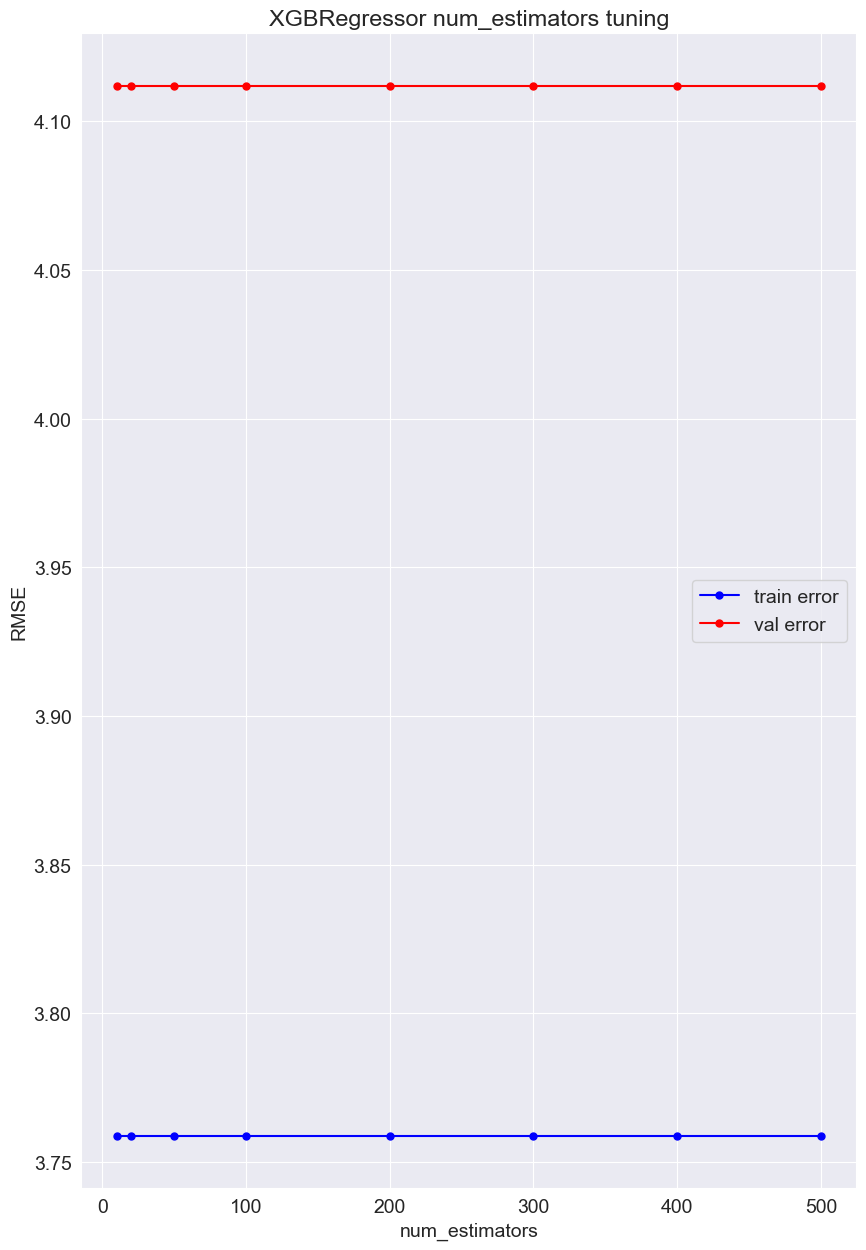

In [96]:
params_tuning_plot(XGBRegressor,'num_estimators',[10,20,50,100,200,300,400,500],best_params)

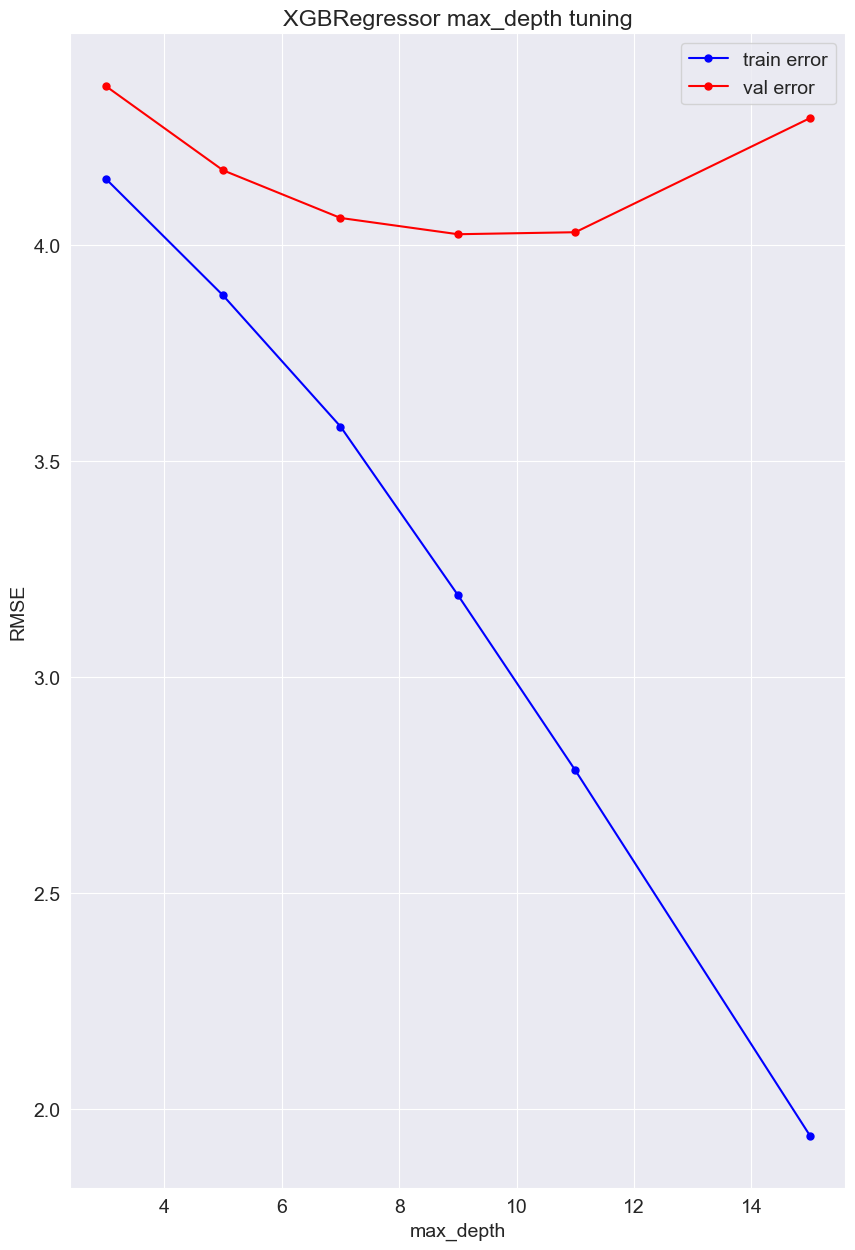

In [97]:
params_tuning_plot(XGBRegressor,'max_depth',[3,5,7,9,11,15],best_params)

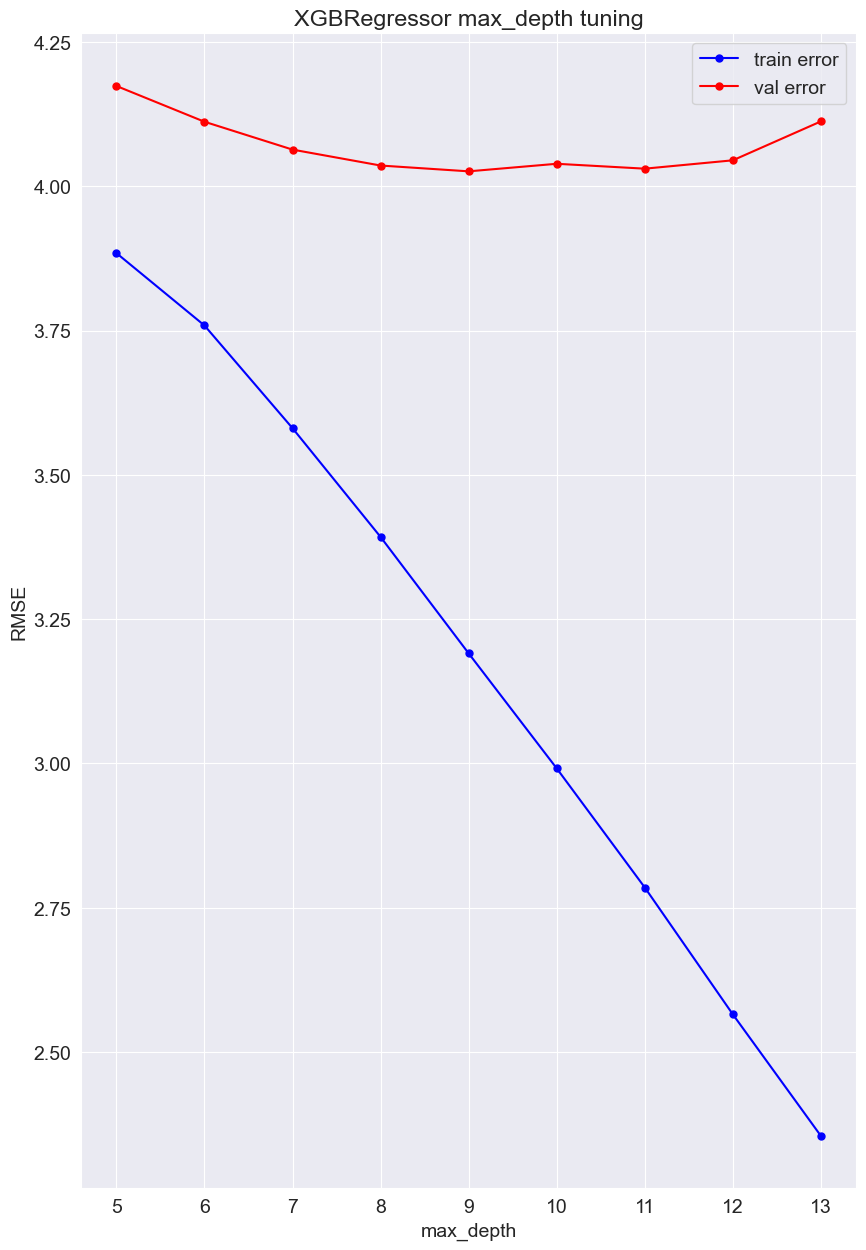

In [103]:
params_tuning_plot(XGBRegressor,'max_depth',[5,6,7,8,9,10,11,12,13],best_params)

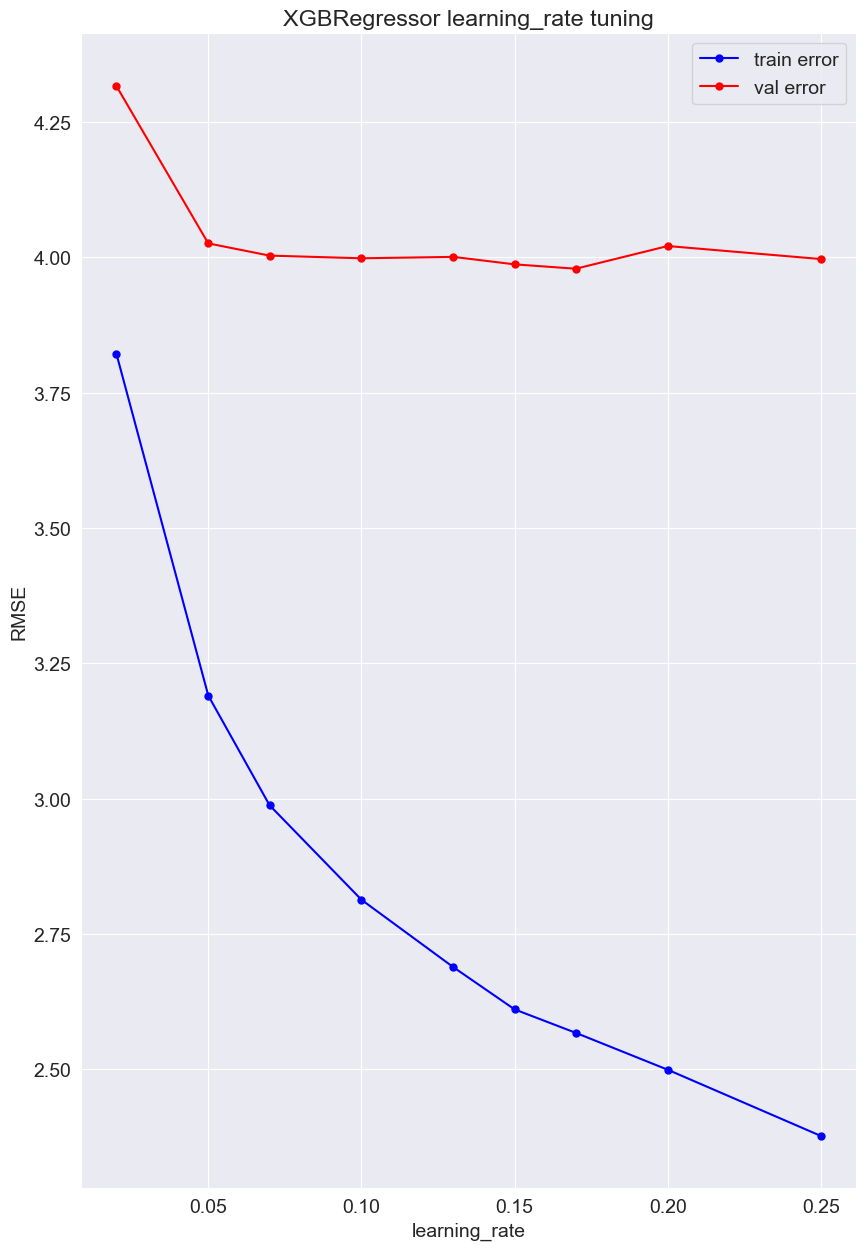

In [104]:
best_params={
    'random_state':42,
    'n_jobs':-1,
    'objective':'reg:squarederror',
    'max_depth':9
}
params_tuning_plot(XGBRegressor,'learning_rate',[0.02,0.05,0.07,0.1,0.13,0.15,0.17,0.2,0.25],best_params)

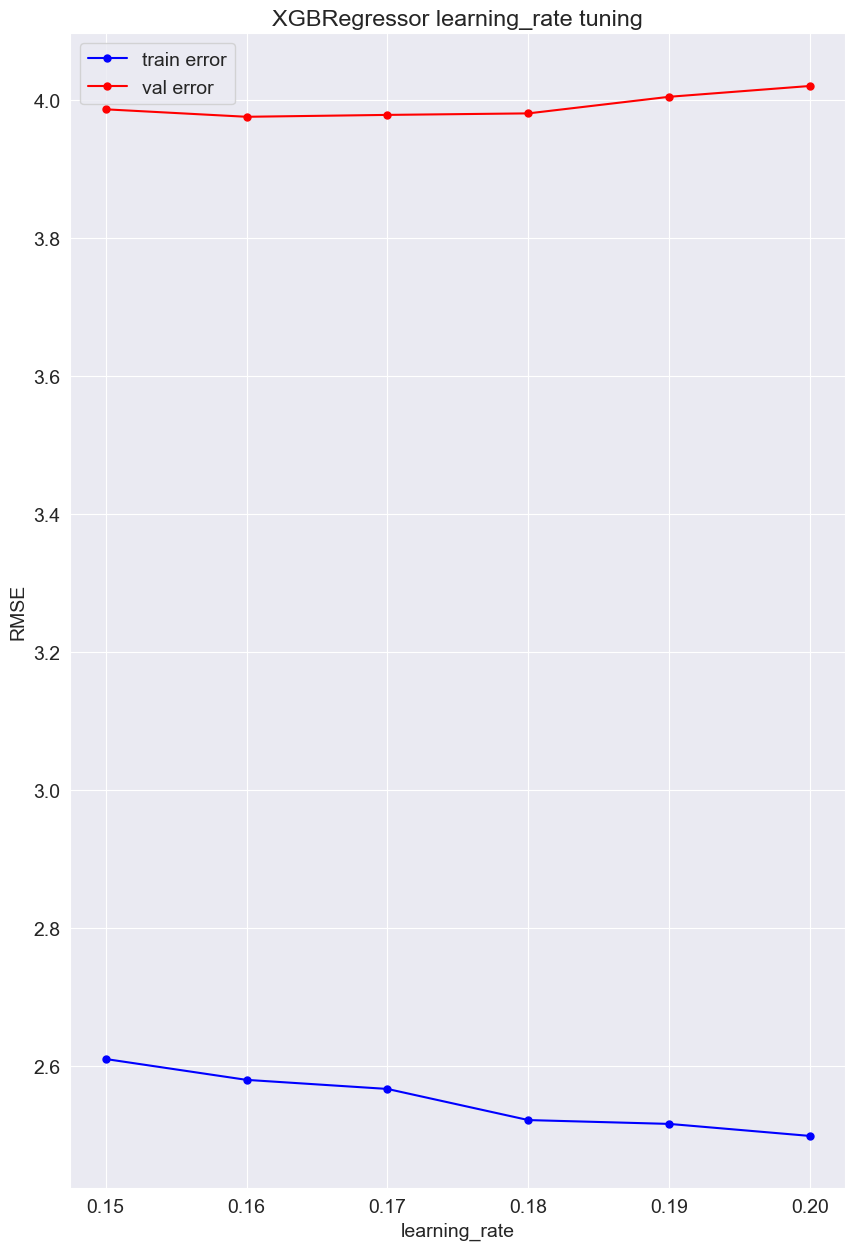

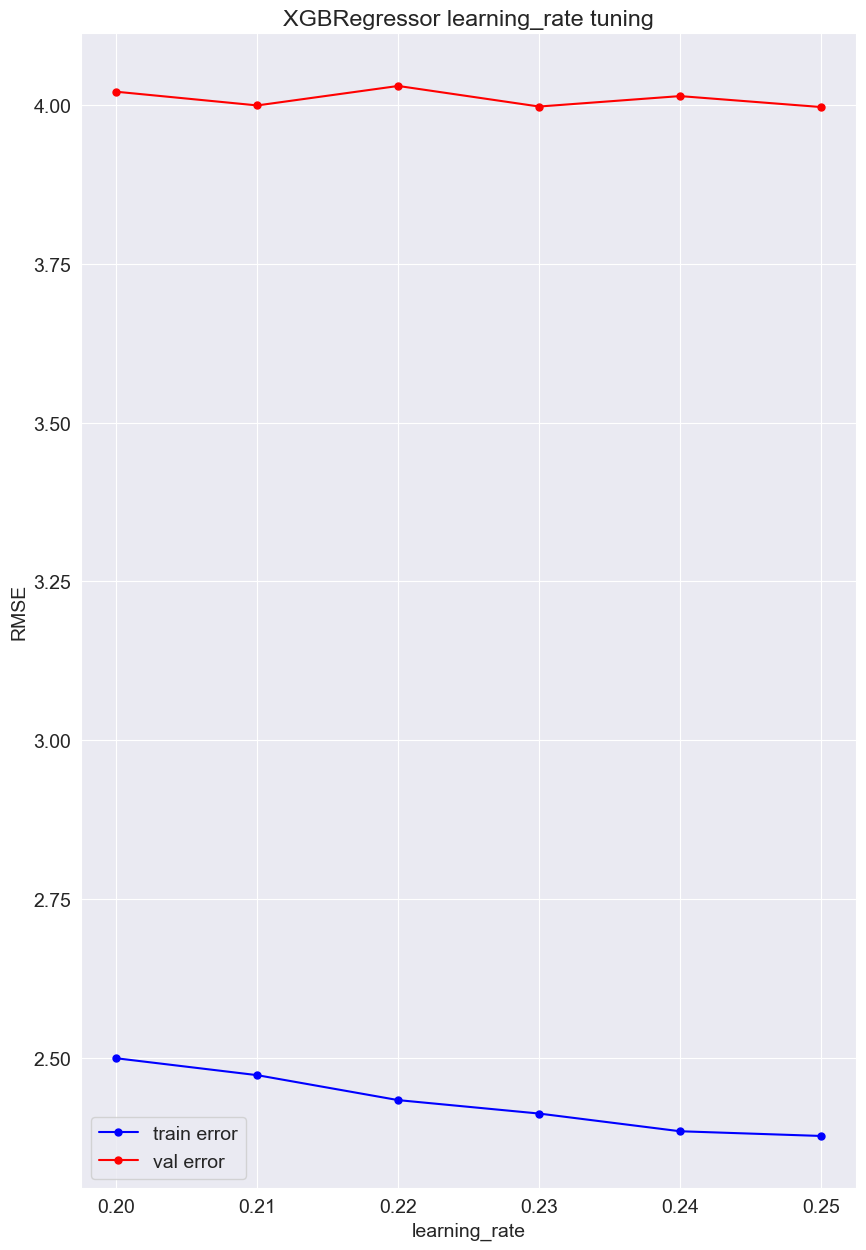

In [105]:
best_params={
    'random_state':42,
    'n_jobs':-1,
    'objective':'reg:squarederror',
    'max_depth':9
}
params_tuning_plot(XGBRegressor,'learning_rate',[0.15,0.16,0.17,0.18,0.19,0.2],best_params)
params_tuning_plot(XGBRegressor,'learning_rate',[0.2,0.21,0.22,0.23,0.24,0.25],best_params)

In [ ]:
best_params={
    'random_state':42,
    'n_jobs':-1,
    'objective':'reg:squarederror',
    'max_depth':9,
    'learning_rate':0.16
}
params_tuning_plot(XGBRegressor,'sub_sample',[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9],best_params)